In [19]:
import matplotlib.pyplot as plt
import numpy as np
from utils import load_image
import gc

class CircleSampler:
    def __init__(self, n_samples, radius=None):
        # self.x = None
        # self.y = None
        self.center = None
        self.points = None
        self.n = n_samples
        self.radius = radius
        self.generate_xy()

    def generate_xy(self):
        u = np.random.rand(self.n)
        theta = np.random.rand(self.n) * 2 * np.pi

        r = np.sqrt(u)
        x = np.cos(theta)
        y = np.sin(theta)

        self.x = x
        self.y = y
        self.r = r
    
    def points_in_circle(self, radius=None, center=(0, 0)):
        self.center = center
        if radius is not None:
            self.radius = radius
        if self.radius is None:
            raise ValueError("Radius must be specified.")

        r = self.r * self.radius
        x = self.x * r + center[0]
        y = self.y * r + center[1]
        self.points = np.column_stack((x, y))
        return self.points

    def get_points(self):
        if self.points is None:
            raise ValueError("Points have not been generated yet.")
        return self.points


def show_mask(mask, ax):
    color = np.array([30 / 255, 144 / 255, 255 / 255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    del mask
    gc.collect()


In [5]:
raw_img = load_image('/data/gas_8feat/raw/after/1.jpg')
raw_img1 = load_image('/data/gas_8feat/raw/before/1.jpg')
mask = np.load('/data/gas_8feat/masks_sorted/after/1.npy')
mask1 = np.load('/data/gas_8feat/masks_sorted/before/1.npy')

In [17]:
x_avg = []
y_avg = []
r = []
for i in range(len(mask)):
    coords = np.where(mask[i] == 1)
    x_avg.append(np.mean(coords[1]))
    y_avg.append(np.mean(coords[0]))
    r.append(np.max(np.sqrt((coords[1] - x_avg[i])**2 + (coords[0] - y_avg[i])**2)))

x_avg1 = []
y_avg1 = []
r1 = []
for i in range(len(mask1)):
    coords = np.where(mask1[i] == 1)
    x_avg1.append(np.mean(coords[1]))
    y_avg1.append(np.mean(coords[0]))
    r1.append(np.max(np.sqrt((coords[1] - x_avg1[i])**2 + (coords[0] - y_avg1[i])**2)))

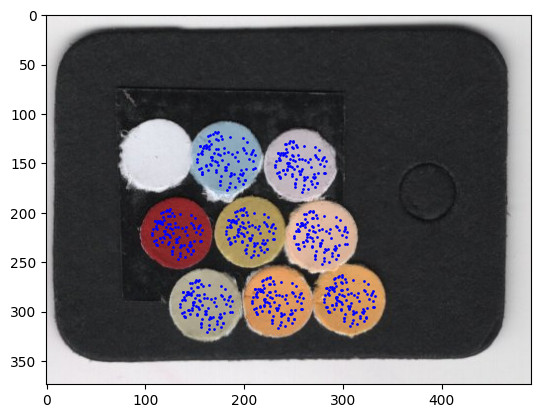

In [20]:
sampler = CircleSampler(n_samples=100)

plt.imshow(np.array(raw_img))
for i in range(len(mask)):
    points = sampler.points_in_circle(radius=r[i], center=(x_avg[i], y_avg[i]))
    plt.scatter(points[:, 0], points[:, 1], s=1, color='blue')

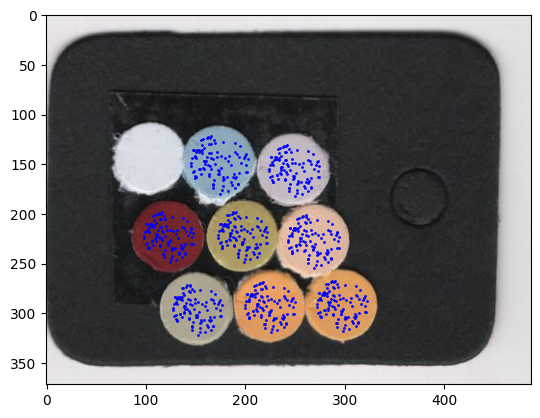

In [24]:
plt.imshow(np.array(raw_img1))
for i in range(len(mask1)):
    points = sampler.points_in_circle(radius=r1[i], center=(x_avg1[i], y_avg1[i]))
    plt.scatter(points[:, 0], points[:, 1], s=1, color='blue')

In [1]:
from utils import *
import os
from tqdm import tqdm
import glob

In [4]:
paths = glob.glob('/data/gas_8feat/raw/after/*.jpg')
n_repeats = 10
sampler = CircleSampler(n_samples=100, repeat=n_repeats)
features = []
# ---提取每个mask的RGB均值特征并保存---
for p in tqdm(paths):
    img = load_image(p)
    img = np.array(img)
    dirname, basename = os.path.dirname(p), os.path.basename(p)
    seg = np.load(os.path.join('/data/gas_sample/masks_sorted_refine/after', basename.replace('.jpg', '.npy'))).astype(bool)    
    feat = []  # all features of one image
    for i in range(len(seg)):
        coords = np.where(seg[i] == 1)
        x_avg = np.mean(coords[1])
        y_avg = np.mean(coords[0])
        r = np.max(np.sqrt((coords[1] - x_avg)**2 + (coords[0] - y_avg)**2))
        points = sampler.points_in_circle(radius=r, center=(x_avg, y_avg))  # [n_repeats, 2, n_samples]
        rgb = []  # r, g, b features for for n_repeats samples
        for xy in points:
            rgb.append(img[xy[0], xy[1]].mean(axis=0).tolist())
        feat.append(np.stack(rgb))
    features.append(np.column_stack(feat))

features = np.vstack(features)

100%|██████████| 140/140 [00:00<00:00, 141.62it/s]


In [6]:
features.shape

(1400, 24)